In [2]:
#임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#사이킷런 -> 머신러닝 알고리즘을 제공하는 라이브러리!
#datasets라는 모듈 -> 분류, 회귀, 군집화, 차원축소 등에 쓰이는 데이터를 불러오기 쉽게 만들어놓음
from sklearn import datasets

In [13]:
#엑셀파일 써도 되는데!-> 이렇게도 쓸수있다~
data = datasets.load_iris()

In [10]:
#data : X(features) -> 머신러닝 훈련 시에 쓰이는 특성 데이터
#target : Y(labels) -> 머신러닝 정답지(비지도..!)
#feature_names : X라는 특성의 이름
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [11]:
#data : X(features)
#iris(붓꽃 데이터) -> 붓꽃의 꽃받침, 꽃잎 종류 데이터
data['data'][0]

array([5.1, 3.5, 1.4, 0.2])

In [14]:
#target : Y(labels) -> 붓꽃 무슨종류? '0'
data['target'][0]

np.int64(0)

In [15]:
data['target'][140] #2번째 종류~

np.int64(2)

In [9]:
data['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [16]:
#1차원, 4개
data['data'][0].shape

(4,)

In [18]:
#data.data = 꽃잎과 꽃받침의 너비, 길이를 표현하는 4차원 데이터 (x1, x2, x3, x4)
x = pd.DataFrame(data['data'], columns=data['feature_names'])

#data.taeget = 어느품종에 속하는가를 0, 1, 2
y = pd.DataFrame(data['target'], columns=['Species'])

# x와 y를 하나의 데이터 프레임으로 만들기 위해
#concat -> concatenate(붙임)
#axis = 0(행 방향으로(아래)붙이겠다), axis = 1(열 방향(옆)으로 붙이겠다)
df = pd.concat([x,y], axis=1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [20]:
#임포트
from sklearn.cluster import KMeans

#정의
# 정해줘야 하는 것? K 개수(n_cluster)
km = KMeans(n_clusters=3)

#훈련 -> 임의로 클래스를 나누는 행위
#비지도 학습은 x만 필요하다
km.fit(x)

#예측 -> 클래스(라벨, 군집)를 나누는 행위
Kms_predict = km.predict(x)

In [22]:
#x를 가지고 군집화를 수행한 결과
print(km.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


In [23]:
#센트로이드 값
print(km.cluster_centers_)

[[6.85       3.07368421 5.74210526 2.07105263]
 [5.006      3.428      1.462      0.246     ]
 [5.9016129  2.7483871  4.39354839 1.43387097]]


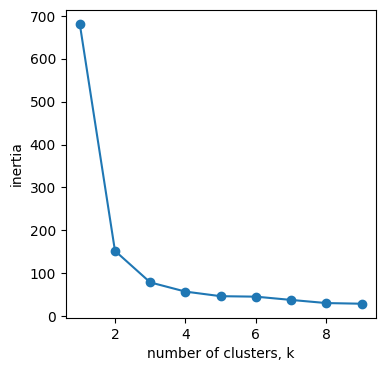

In [24]:
#엘보우 그래프
# 적절한 K에 대해 붓꽃 데이터프레임을 넣어 K와 inertia를 비교
# 값(3)이 적합한 변화시점임을 알 수 있음
scope = range(1,10)
inertias = []

for k in scope:
    model = KMeans(n_clusters=k)
    model.fit(X)
    inertias.append(model.inertia_)

# K 개수와 inertia 비교 시각화
#그림의 크기를 정하는 부분(4,4)
plt.figure(figsize=(4, 4))

#점과 선으로 이루어진 그래프를 그리겠다,
#scope = x
#inertias = y
plt.plot(scope, inertias, '-o')

plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.show()

In [ ]:
from